Goals:
   - Use Digital Archaeology skills and fundamentals to analyze texts for certain patterns and trends.

Idea:
   - Find a certain work that has multiple translations and compare the words contained in each translation. 

Examples:
   - Homer's Odyssey
  -  The Bible
   - Other Old Greek/Roman works
  -  Shakespeare modern rewrites

In [10]:
import re
import requests
from bs4 import BeautifulSoup

# Add the Project Gutenberg links for the books you want to compare.
book_urls = {
    "S. Butler": "https://www.gutenberg.org/cache/epub/1727/pg1727.txt",
    "A. Pope": "https://www.gutenberg.org/cache/epub/3160/pg3160.txt",
    "S. H. Butcher, A. Lang": "https://www.gutenberg.org/cache/epub/1728/pg1728.txt",
    "G. Chapman": "https://www.gutenberg.org/cache/epub/48895/pg48895.txt",
    "W. Cowper": "https://www.gutenberg.org/cache/epub/24269/pg24269.txt",
    "M. E. Burt": "https://www.gutenberg.org/cache/epub/24856/pg24856.txt",
    "H. L. Havell": "https://www.gutenberg.org/cache/epub/13725/pg13725.txt",
    "G. Thorne": "https://www.gutenberg.org/cache/epub/41935/pg41935.txt",
    "A. J. Church": "https://www.gutenberg.org/cache/epub/6370/pg6370.txt",
    "K. F. Becker": "https://www.gutenberg.org/cache/epub/59750/pg59750.txt",
    

}


def get_word_count(url):
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    # BeautifulSoup also works when Gutenberg returns plain text rather than HTML.
    text = BeautifulSoup(response.text, "html.parser").get_text(" ")
    words = re.findall(r"[A-Za-z]+(?:['-][A-Za-z]+)*", text.lower())
    return len(words)


word_counts = {
    title: get_word_count(url)
    for title, url in book_urls.items()
    if url.strip()
}

word_counts

{'S. Butler': 132669,
 'A. Pope': 128098,
 'S. H. Butcher, A. Lang': 145561,
 'G. Chapman': 184116,
 'W. Cowper': 120349,
 'M. E. Burt': 51637,
 'H. L. Havell': 71813,
 'G. Thorne': 26648,
 'A. J. Church': 48785,
 'K. F. Becker': 42071}

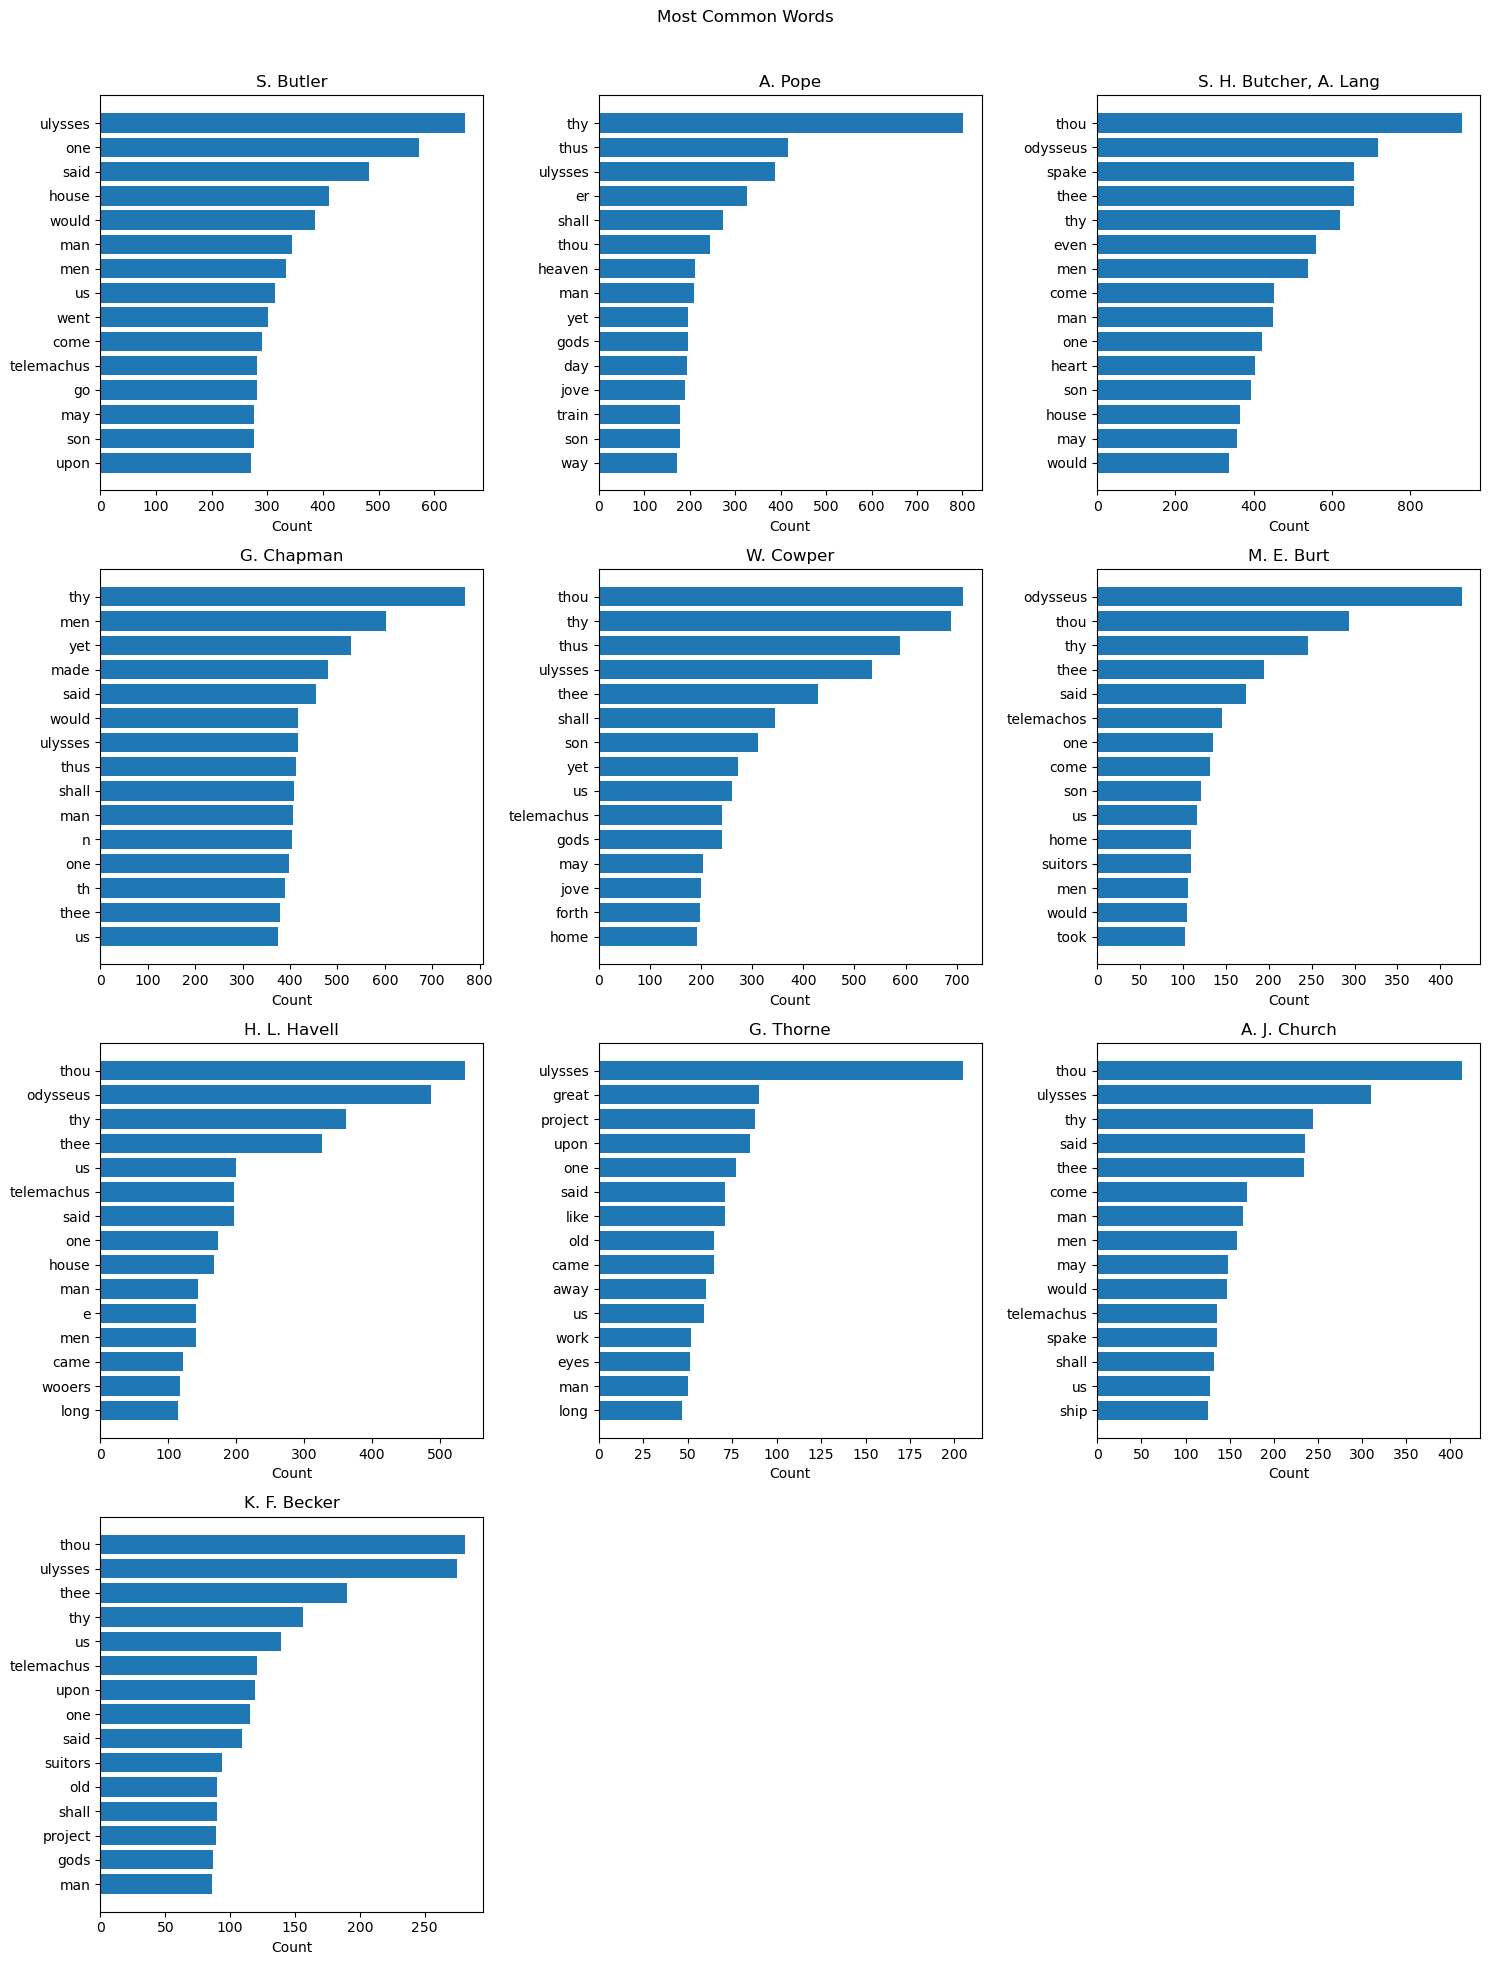

In [14]:
from collections import Counter
import math
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords", quiet=True)
    stop_words = set(stopwords.words("english"))

stop_words.add("gutenberg")


def get_word_frequencies(url):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text = BeautifulSoup(response.text, "html.parser").get_text(" ")
    words = re.findall(r"[A-Za-z]+(?:['-][A-Za-z]+)*", text.lower())
    return Counter(word for word in words if word not in stop_words)


book_frequencies = {
    title: get_word_frequencies(url)
    for title, url in book_urls.items()
    if url.strip()
}

columns = 3
rows = math.ceil(len(book_frequencies) / columns)
fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(15, 5 * rows),
    squeeze=False,
)
axes = axes.flatten()

for axis, (title, frequencies) in zip(axes, book_frequencies.items()):
    most_common = frequencies.most_common(15)[::-1]
    words = [word for word, count in most_common]
    counts = [count for word, count in most_common]
    axis.barh(words, counts)
    axis.set_title(title)
    axis.set_xlabel("Count")

# Hide empty subplot slots when the number of books is not a multiple of three.
for axis in axes[len(book_frequencies):]:
    axis.set_visible(False)

fig.suptitle("Most Common Words")
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

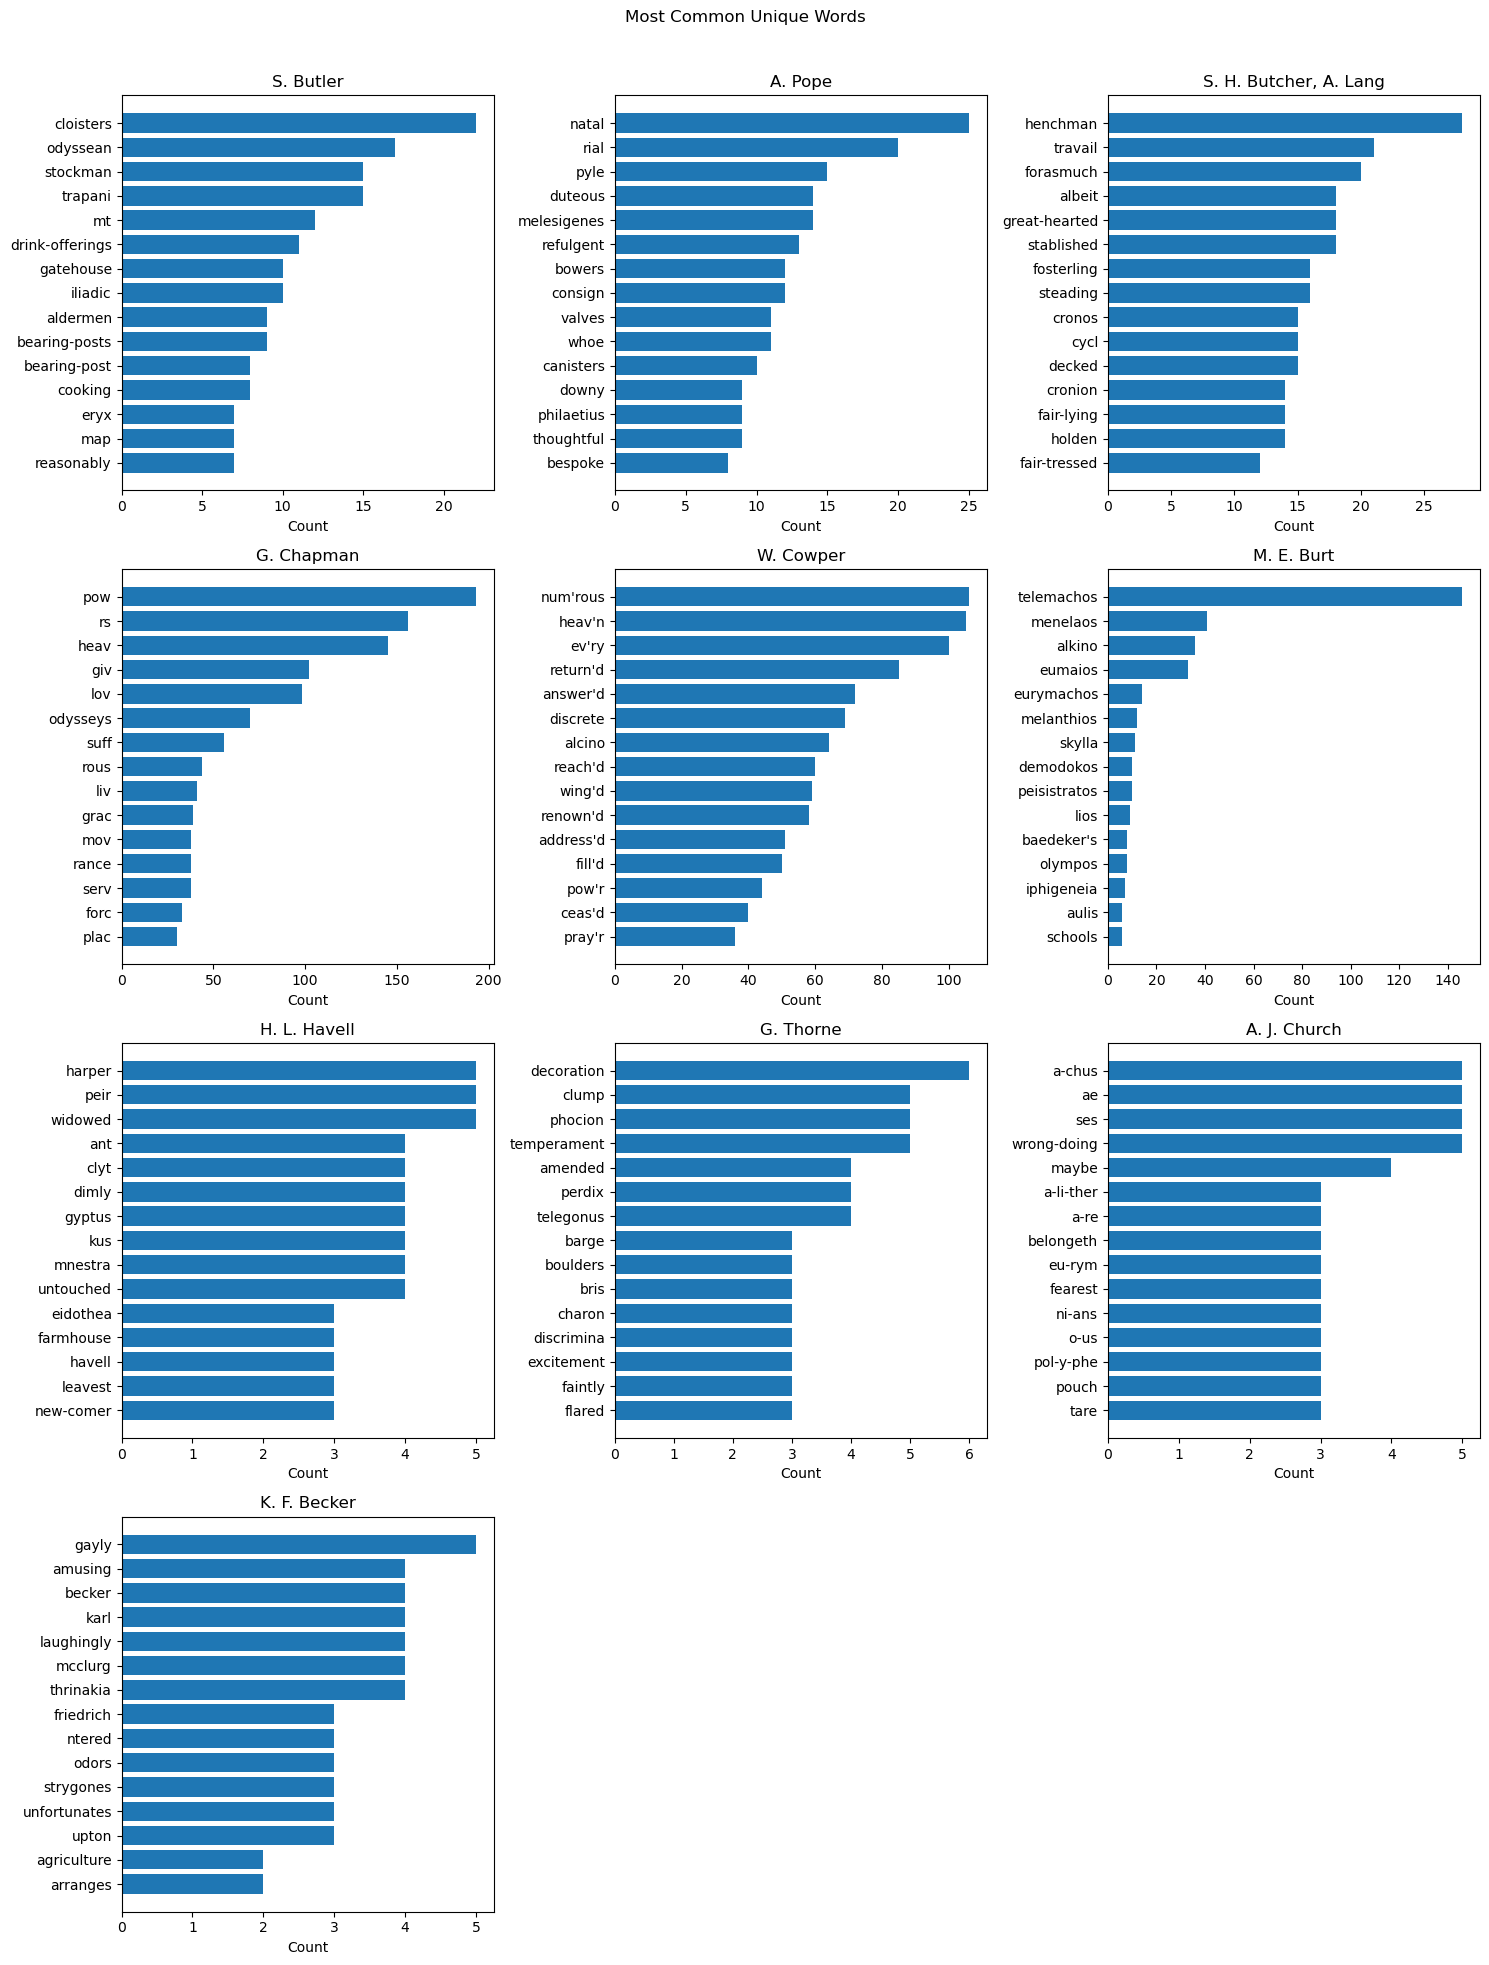

In [16]:
unique_frequencies_by_book = {
    title: Counter({word: frequencies[word] for word in unique_words_by_book[title]})
    for title, frequencies in book_frequencies.items()
}

columns = 3
rows = math.ceil(len(unique_frequencies_by_book) / columns)
fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(15, 5 * rows),
    squeeze=False,
)
axes = axes.flatten()

for axis, (title, frequencies) in zip(axes, unique_frequencies_by_book.items()):
    most_common = frequencies.most_common(15)[::-1]
    words = [word for word, count in most_common]
    counts = [count for word, count in most_common]
    axis.barh(words, counts)
    axis.set_title(title)
    axis.set_xlabel("Count")

# Hide empty subplot slots when the number of books is not a multiple of three.
for axis in axes[len(unique_frequencies_by_book):]:
    axis.set_visible(False)

fig.suptitle("Most Common Unique Words")
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

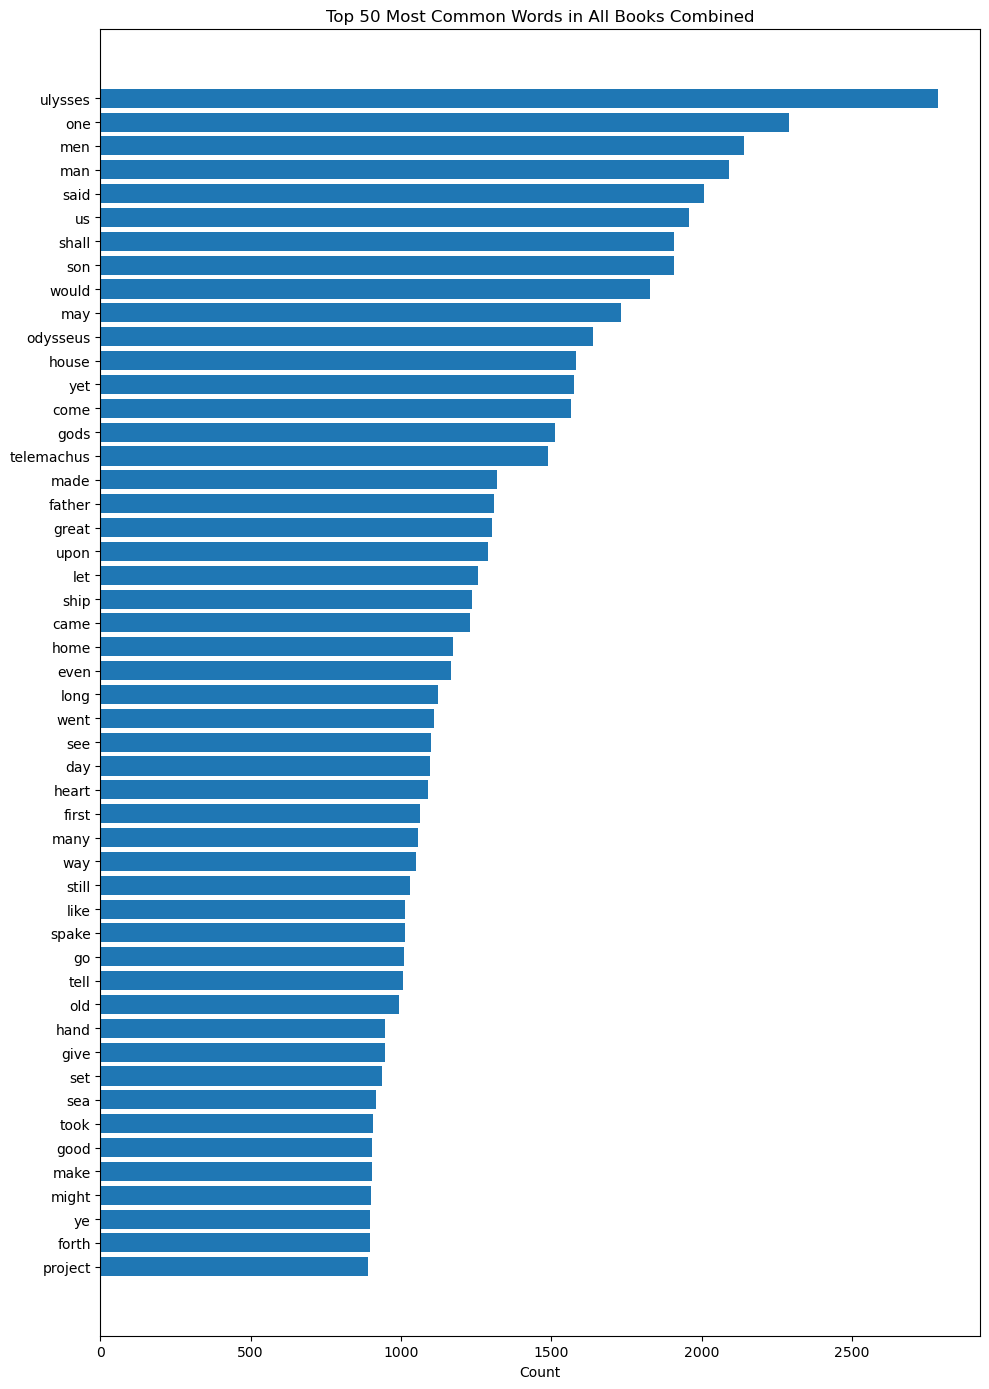

In [19]:
combined_stop_words = {"thy", "thou", "thee", "thus"}
combined_frequencies = Counter()

for frequencies in book_frequencies.values():
    combined_frequencies.update(
        {
            word: count
            for word, count in frequencies.items()
            if word not in combined_stop_words
        }
    )

most_common_combined = combined_frequencies.most_common(50)[::-1]
words = [word for word, count in most_common_combined]
counts = [count for word, count in most_common_combined]

plt.figure(figsize=(10, 14))
plt.barh(words, counts)
plt.title("Top 50 Most Common Words in All Books Combined")
plt.xlabel("Count")
plt.tight_layout()
plt.show()